# EDA for pipe replacement planning

Goal: understand `pipes.csv` (the network) and `train.csv` (2019-2026 leak
history) well enough to design a work-unit strategy that replaces every
iron pipe by 2052 under a $10M/year budget, while minimizing earthwork
cost and leak cost.

This notebook focuses on the questions that directly shape the plan:
1. What materials/surfaces exist, and how do they combine (drives the
   surface-rate cost term)?
2. Which pipes have *already* been replaced (via a leak) before the 2027
   project window starts?
3. What does leak risk look like as a function of material, surface, and
   pipe age — and is it changing over time?
4. How dense/clustered is the iron network spatially — how many pipes
   could plausibly be swept up by one work-unit circle?
5. A rough budget sanity check: total iron length vs. 25-year budget.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from scipy.spatial import cKDTree

load_dotenv()

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW_DIR = PROJECT_ROOT / os.getenv("DATA_RAW_DIR", "data/raw")
DATA_PROCESSED_DIR = PROJECT_ROOT / os.getenv("DATA_PROCESSED_DIR", "data/processed")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
pipes = pd.read_csv(DATA_RAW_DIR / "pipes.csv", parse_dates=["Lay date"])
leaks = pd.read_csv(DATA_RAW_DIR / "train.csv", parse_dates=["Date"])

print("pipes:", pipes.shape)
print("leaks:", leaks.shape)
pipes.head()

pipes: (43039, 8)
leaks: (14113, 4)


,Pipe ID,Lay date,Material,Surface,GPS x1,GPS y1,GPS x2,GPS y2
0,P01001,1955-03-11,copper,grassland,6136.29,5020.97,6124.15,5020.97
1,P01002,1971-09-19,cast iron,water,6512.35,4147.58,6536.59,4201.94
2,P01003,1971-09-18,cast iron,water,6536.59,4201.94,6518.42,4201.93
3,P01004,1982-05-22,cast iron,structure,2836.68,3377.95,2848.80,3405.12
4,P01005,1971-07-03,cast iron,water,5117.28,4272.91,5126.37,4297.16


In [3]:
leaks.head()

,Pipe ID,Date,Time,Cost
0,P19711,2019-01-06,08:20,2074.90
1,P07628,2019-01-07,00:00,618.71
2,P31195,2019-04-16,03:48,1050.07
3,P15715,2019-04-16,16:51,1000.81
4,P10415,2019-04-17,22:08,3157.83


In [4]:
print("pipes.csv NA counts:")
print(pipes.isna().sum())
print("\ntrain.csv NA counts:")
print(leaks.isna().sum())

pipes.csv NA counts:
Pipe ID      0
Lay date    15
Material     8
Surface      0
GPS x1       0
GPS y1       0
GPS x2       0
GPS y2       0
dtype: int64

train.csv NA counts:
Pipe ID    0
Date       0
Time       0
Cost       0
dtype: int64


### Missing values: what are they, and do they matter?

8 pipes are missing `Material`, 15 are missing `Lay date`. Given the
mandate ("every iron pipe" must end up replaced), we need to know whether
these missing values could hide an iron pipe we'd otherwise skip.

In [5]:
missing_material = pipes.loc[pipes["Material"].isna()]
missing_lay_date = pipes.loc[pipes["Lay date"].isna()]
print("Pipes missing Material (all surfaces):", missing_material["Surface"].value_counts().to_dict())
print("None of these appear in train.csv (i.e. not provably already-replaced):",
      not set(missing_material["Pipe ID"]) & set(leaks["Pipe ID"]))
print()
print("Pipes missing Lay date -- Material breakdown:", missing_lay_date["Material"].value_counts().to_dict())

Pipes missing Material (all surfaces): {'water': 8}
None of these appear in train.csv (i.e. not provably already-replaced): True

Pipes missing Lay date -- Material breakdown: {'wrought iron': 15}


- The 8 missing-`Material` pipes are all on `water` surface and never
  appear in `train.csv`, so we cannot tell if they're iron, copper, brass,
  or already polyurethane from the data alone. Treating them as iron
  (i.e. include them in the replacement set) is the conservative choice
  that can't cause a spec rejection; treating them as already-fine would
  risk leaving an iron pipe unreplaced.
- The 15 missing-`Lay date` pipes are all `wrought iron` -- their
  material is known, so they still must be replaced; only the age-based
  part of a risk score is affected, and can be imputed (e.g. cohort
  median lay date) without threatening compliance.

## 1. Materials and surfaces

`pipes.csv`'s `Material` column mixes truly-original materials with pipes
that leaked *before* 2019 (unknown to us) and were already polyurethane.
We need the exact set of non-polyurethane material labels to know what
counts as "iron" for the mandate (the project text says "iron", but the
data may encode multiple iron alloys, e.g. cast iron / wrought iron).

In [6]:
pipe_length = np.hypot(
    pipes["GPS x2"] - pipes["GPS x1"], pipes["GPS y2"] - pipes["GPS y1"]
)
pipes["length_m"] = pipe_length

material_summary = (
    pipes.groupby("Material")
    .agg(n_pipes=("Pipe ID", "count"), total_length_m=("length_m", "sum"))
    .assign(pct_of_pipes=lambda d: 100 * d["n_pipes"] / len(pipes))
    .sort_values("n_pipes", ascending=False)
)
material_summary

,n_pipes,total_length_m,pct_of_pipes
Material,,,
wrought iron,24562,265841.767497,57.069170
cast iron,10630,275866.875435,24.698529
gray iron,3263,127555.259152,7.581496
polyurethane,1678,17847.406396,3.898789
copper,1613,62029.475416,3.747764
brass,1285,14221.044021,2.985664


In [7]:
surface_summary = (
    pipes.groupby("Surface")
    .agg(n_pipes=("Pipe ID", "count"), total_length_m=("length_m", "sum"))
    .sort_values("n_pipes", ascending=False)
)
surface_summary

,n_pipes,total_length_m
Surface,,
grassland,13507,183407.842373
water,12824,261739.623342
farmland,6531,76203.379388
structure,5680,140240.037188
road,2324,58179.619690
swamp,2173,43684.774825


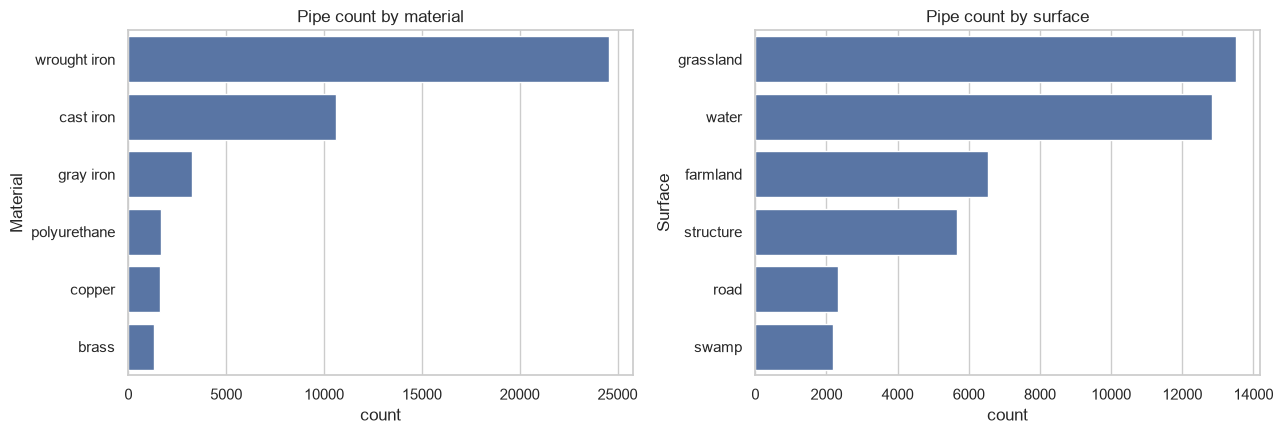

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=pipes, y="Material", order=material_summary.index, ax=axes[0])
axes[0].set_title("Pipe count by material")
sns.countplot(data=pipes, y="Surface", order=surface_summary.index, ax=axes[1])
axes[1].set_title("Pipe count by surface")
plt.tight_layout()
plt.show()

### Material x Surface cross-tab

This matters because a work-unit's surface rate is the **sum of the rates
of every distinct surface type appearing among all pipes wholly inside the
circle** (not just the iron ones) — so a circle that clips a few
structure/water pipes on the edge of an otherwise cheap grassland cluster
gets the expensive rate too. Understanding how surfaces co-locate with
iron pipes tells us how "clean" we can make our circles.

In [9]:
pd.crosstab(pipes["Material"], pipes["Surface"])

Surface,farmland,grassland,road,structure,swamp,water
Material,,,,,,
brass,0,336,40,802,57,50
cast iron,2072,2311,590,1754,549,3354
copper,17,138,86,400,0,972
gray iron,102,931,375,515,304,1036
polyurethane,211,639,22,0,0,806
wrought iron,4129,9152,1211,2209,1263,6598


## 2. Pipes already replaced before the project window

Per the project notes, pipes that leaked in 2019-2026 were already
repaired with polyurethane — `pipes.csv`'s `Material` still shows the
*original* material for those pipes. So the set of pipes that actually
need a work unit in 2027+ is:

`non-polyurethane in pipes.csv` MINUS `pipes that already appear in train.csv`

Let's quantify this and check whether any pipe leaked more than once
(which would be surprising, since a first leak converts it to
polyurethane).

In [10]:
n_dup_pipe_ids = leaks["Pipe ID"].duplicated().sum()
print("Duplicate Pipe IDs in train.csv (pipe leaked >1x):", n_dup_pipe_ids)
print("Distinct pipes with at least one leak:", leaks["Pipe ID"].nunique())

Duplicate Pipe IDs in train.csv (pipe leaked >1x): 0
Distinct pipes with at least one leak: 14113


In [11]:
already_replaced_ids = set(leaks["Pipe ID"].unique())
pipes["already_replaced_pre_2027"] = pipes["Pipe ID"].isin(already_replaced_ids)
pipes["is_polyurethane"] = pipes["Material"].eq("polyurethane")

pipes["effective_material_2027"] = np.where(
    pipes["already_replaced_pre_2027"] | pipes["is_polyurethane"],
    "polyurethane",
    pipes["Material"],
)

print(pipes["already_replaced_pre_2027"].value_counts())
print()
print("Original Material counts (raw pipes.csv):")
print(pipes["Material"].value_counts())
print()
print("Effective material as of 2027 (accounting for pre-window leak repairs):")
print(pipes["effective_material_2027"].value_counts())

already_replaced_pre_2027
False    28926
True     14113
Name: count, dtype: int64

Original Material counts (raw pipes.csv):
Material
wrought iron    24562
cast iron       10630
gray iron        3263
polyurethane     1678
copper           1613
brass            1285
Name: count, dtype: int64

Effective material as of 2027 (accounting for pre-window leak repairs):
effective_material_2027
wrought iron    16697
polyurethane    15791
cast iron        7390
gray iron        2150
copper            696
brass             307
Name: count, dtype: int64


In [12]:
# Sanity check: pipes recorded as leaking should NOT already be labelled
# polyurethane in pipes.csv (that would be a data contradiction).
contradictions = pipes.loc[
    pipes["already_replaced_pre_2027"] & pipes["is_polyurethane"]
]
print("Pipes marked polyurethane in pipes.csv that also appear in train.csv:", len(contradictions))

Pipes marked polyurethane in pipes.csv that also appear in train.csv: 0


## 3. Leak risk analysis (train.csv, 2019-2026)

We want to know: which pipes are likely to leak in 2027+ if left
unreplaced, so the work-unit ordering can prioritize them (a leak that
happens before its work unit executes still costs the project money, but
the pipe itself becomes "free" polyurethane by the time we get to it).

In [13]:
leaks_j = leaks.merge(
    pipes[["Pipe ID", "Material", "Surface", "Lay date", "length_m", "GPS x1", "GPS y1", "GPS x2", "GPS y2"]],
    on="Pipe ID",
    how="left",
)
leaks_j["year"] = leaks_j["Date"].dt.year
leaks_j["pipe_age_at_leak_years"] = (
    leaks_j["Date"] - leaks_j["Lay date"]
).dt.days / 365.25

print("Leaks with no matching pipe record:", leaks_j["Material"].isna().sum())
leaks_j[["Pipe ID", "Date", "Cost", "Material", "Surface", "pipe_age_at_leak_years"]].head()

Leaks with no matching pipe record: 0


,Pipe ID,Date,Cost,Material,Surface,pipe_age_at_leak_years
0,P19711,2019-01-06,2074.90,wrought iron,farmland,56.303901
1,P07628,2019-01-07,618.71,gray iron,grassland,53.774127
2,P31195,2019-04-16,1050.07,wrought iron,grassland,71.006160
3,P15715,2019-04-16,1000.81,wrought iron,structure,53.330595
4,P10415,2019-04-17,3157.83,wrought iron,swamp,65.842574


In [14]:
leaks_per_year = leaks_j.groupby("year").agg(
    n_leaks=("Pipe ID", "count"), total_cost=("Cost", "sum"), mean_cost=("Cost", "mean")
)
leaks_per_year

,n_leaks,total_cost,mean_cost
year,,,
2019,1078,1.859418e+07,17248.774091
2020,703,1.360090e+07,19346.948293
2021,866,2.901065e+07,33499.592656
2022,2874,1.073254e+08,37343.577495
2023,1826,4.269122e+07,23379.635931
2024,1955,2.807072e+07,14358.426005
2025,1773,4.265588e+07,24058.591957
2026,3038,7.104871e+07,23386.672041


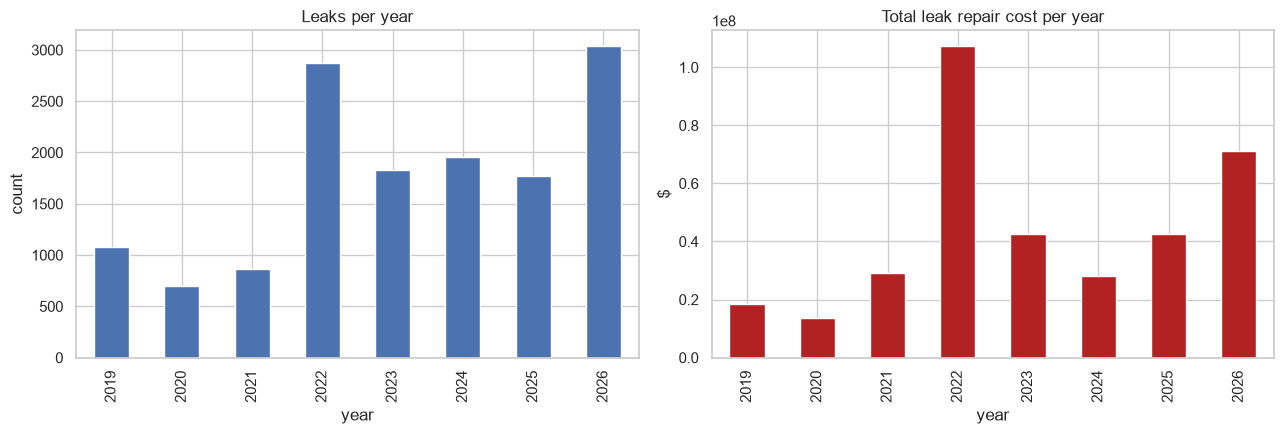

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
leaks_per_year["n_leaks"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Leaks per year")
axes[0].set_ylabel("count")
leaks_per_year["total_cost"].plot(kind="bar", ax=axes[1], color="firebrick")
axes[1].set_title("Total leak repair cost per year")
axes[1].set_ylabel("$")
plt.tight_layout()
plt.show()

If leak counts/costs trend upward as the (fixed) 2019-2026 network ages,
that's evidence the *remaining* iron network's leak hazard will keep
rising after 2026 too — reinforcing "replace old/high-risk iron early."

In [16]:
print("Leak cost summary ($):")
leaks_j["Cost"].describe()

Leak cost summary ($):


count    1.411300e+04
mean     2.501224e+04
std      1.560856e+05
min      1.978000e+01
25%      1.425470e+03
50%      3.275200e+03
75%      9.246170e+03
max      7.257576e+06
Name: Cost, dtype: float64

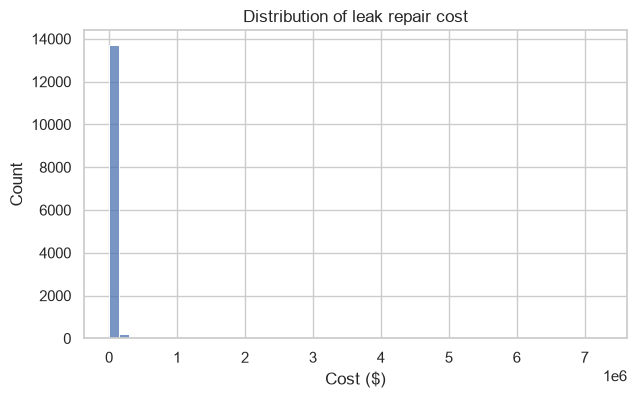

In [17]:
plt.figure(figsize=(7, 4))
sns.histplot(leaks_j["Cost"], bins=50)
plt.title("Distribution of leak repair cost")
plt.xlabel("Cost ($)")
plt.show()

### Leak rate by material and surface

Raw leak counts aren't enough — we need leak counts *relative to how many
pipes/how much length of that material or surface exists*, otherwise a
material with more count of pipes will look riskier by pipe count alone,
only because it's more common.

In [18]:
leak_counts_by_material = leaks_j.groupby("Material")["Pipe ID"].count()
exposure_by_material = pipes.groupby("Material").agg(
    n_pipes=("Pipe ID", "count"), total_length_m=("length_m", "sum")
)
risk_by_material = exposure_by_material.join(
    leak_counts_by_material.rename("n_leaks_2019_2026")
).fillna({"n_leaks_2019_2026": 0})
risk_by_material["leaks_per_1000_pipes"] = (
    1000 * risk_by_material["n_leaks_2019_2026"] / risk_by_material["n_pipes"]
)
risk_by_material["leaks_per_km"] = (
    1000 * risk_by_material["n_leaks_2019_2026"] / risk_by_material["total_length_m"]
)
risk_by_material.sort_values("leaks_per_km", ascending=False)

,n_pipes,total_length_m,n_leaks_2019_2026,leaks_per_1000_pipes,leaks_per_km
Material,,,,,
brass,1285,14221.044021,978.0,761.089494,68.771322
wrought iron,24562,265841.767497,7865.0,320.210081,29.585268
copper,1613,62029.475416,917.0,568.505890,14.783294
cast iron,10630,275866.875435,3240.0,304.797742,11.744795
gray iron,3263,127555.259152,1113.0,341.097150,8.725630
polyurethane,1678,17847.406396,0.0,0.000000,0.000000


In [19]:
leak_counts_by_surface = leaks_j.groupby("Surface")["Pipe ID"].count()
exposure_by_surface = pipes.groupby("Surface").agg(
    n_pipes=("Pipe ID", "count"), total_length_m=("length_m", "sum")
)
risk_by_surface = exposure_by_surface.join(
    leak_counts_by_surface.rename("n_leaks_2019_2026")
).fillna({"n_leaks_2019_2026": 0})
risk_by_surface["leaks_per_km"] = (
    1000 * risk_by_surface["n_leaks_2019_2026"] / risk_by_surface["total_length_m"]
)
risk_by_surface.sort_values("leaks_per_km", ascending=False)

,n_pipes,total_length_m,n_leaks_2019_2026,leaks_per_km
Surface,,,,
farmland,6531,76203.379388,2076,27.242886
grassland,13507,183407.842373,3819,20.822447
swamp,2173,43684.774825,810,18.541929
water,12824,261739.623342,4680,17.880365
road,2324,58179.619690,835,14.352105
structure,5680,140240.037188,1893,13.498285


### Leak *cost* by material and surface (not just frequency)

Prioritization should be driven by *expected* repair cost (probability of
leaking x cost given a leak), not leak frequency alone. Frequency and
severity can point in different directions.

In [20]:
cost_by_material = leaks_j.groupby("Material")["Cost"].agg(["median", "mean", "count"])
cost_by_material

,median,mean,count
Material,,,
brass,9400.725,42410.811084,978
cast iron,3825.620,26986.314880,3240
copper,1533.390,7306.972279,917
gray iron,7457.920,39673.996496,1113
wrought iron,2689.860,22024.999135,7865


In [21]:
cost_by_surface = leaks_j.groupby("Surface")["Cost"].agg(["median", "mean", "count"])
cost_by_surface

,median,mean,count
Surface,,,
farmland,2385.375,5767.722765,2076
grassland,2550.380,6035.605716,3819
road,71591.530,232300.236934,835
structure,11849.910,48994.117517,1893
swamp,3381.130,6404.154259,810
water,2357.040,5570.513972,4680


**`road` leaks are in a different universe of cost**: median $71,592 /
mean $232,300 per leak, vs. roughly $2,000-12,000 (median) for every
other surface. `road` was only mid-pack on leaks-per-km (14.4), so this
is a severity signal, not a frequency signal -- easy to miss if we only
looked at leak counts. `brass` and `gray iron` also have the highest
per-leak cost among materials (median ~$7,500-9,400), well above
`wrought iron`/`cast iron` (~$2,700-3,800) despite `wrought iron` leaking
more often. So the true risk ranking for prioritization is
`P(leak) x E[cost | leak]`, not leak-rate alone.

This also lets us sanity-check "is it ever cheaper to let a pipe leak
and get its replacement for free?" On average, no: replacing a
to-be-replaced pipe proactively saves ~$200/m x avg length (~17.3 m) =
**~$3,460** in linear cost at execution time. That's smaller than the
*mean* leak cost on every surface except farmland/grassland/water, and
far smaller than the median leak cost on `road` or `structure` -- i.e.
for most of the network, letting a pipe leak instead of replacing it
early is a net loss in expectation, sometimes a very large one.

### Leak hazard vs. pipe age

Pipe age at the time of laying (`Lay date`) relative to leak date. If
hazard clearly increases with age, that's a strong, simple prioritization
signal (replace oldest iron first) independent of any survival model.

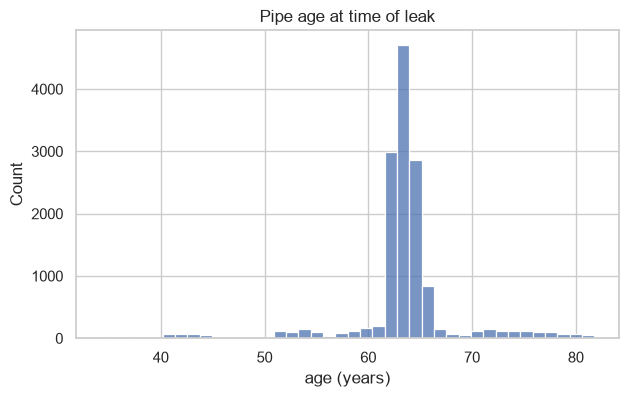

In [22]:
plt.figure(figsize=(7, 4))
sns.histplot(leaks_j["pipe_age_at_leak_years"].dropna(), bins=40)
plt.title("Pipe age at time of leak")
plt.xlabel("age (years)")
plt.show()

In [23]:
pipes["lay_year"] = pipes["Lay date"].dt.year
age_bins = [0, 20, 40, 60, 80, 100, 200]
pipes["age_bin_2019"] = pd.cut(2019 - pipes["lay_year"], bins=age_bins)
leaks_j["age_bin_2019"] = pd.cut(2019 - leaks_j["Lay date"].dt.year, bins=age_bins)

exposure_by_age = pipes.groupby("age_bin_2019", observed=True)["Pipe ID"].count()
leaks_by_age = leaks_j.groupby("age_bin_2019", observed=True)["Pipe ID"].count()
age_risk = pd.DataFrame({"n_pipes": exposure_by_age, "n_leaks": leaks_by_age}).fillna(0)
age_risk["leak_rate_per_1000"] = 1000 * age_risk["n_leaks"] / age_risk["n_pipes"]
age_risk

,n_pipes,n_leaks,leak_rate_per_1000
age_bin_2019,,,
"(20, 40]",1558,331,212.451861
"(40, 60]",19696,9202,467.201462
"(60, 80]",21770,4574,210.105650


## 4. Spatial structure: how clustered is the iron network?

Work units are circles, and cost scales with `area^0.85` plus a $200/m
linear term for non-poly pipe length caught inside. To plan circle sizing
we need a sense of typical nearest-neighbor spacing between non-poly
pipes — tight clusters support small, cheap, high-yield circles; sparse
pipes force either large (expensive-area) circles or many small ones
(more $100 base fees).

In [24]:
non_poly = pipes.loc[pipes["effective_material_2027"] != "polyurethane"].copy()
non_poly["mid_x"] = (non_poly["GPS x1"] + non_poly["GPS x2"]) / 2
non_poly["mid_y"] = (non_poly["GPS y1"] + non_poly["GPS y2"]) / 2

print("Pipes still needing replacement in 2027:", len(non_poly))
print("Total length needing replacement (m):", non_poly["length_m"].sum())

coords = non_poly[["mid_x", "mid_y"]].to_numpy()
tree = cKDTree(coords)
dist, _ = tree.query(coords, k=2)  # k=1 is self (dist 0)
nn_dist = dist[:, 1]

print("\nNearest-neighbor midpoint distance among pipes-to-replace (m):")
print(pd.Series(nn_dist).describe())

Pipes still needing replacement in 2027: 27248
Total length needing replacement (m): 471776.77161987

Nearest-neighbor midpoint distance among pipes-to-replace (m):
count    27248.000000
mean        11.309174
std         11.893525
min          0.029155
25%          3.465758
50%          7.905708
75%         13.571903
max        131.531302
dtype: float64


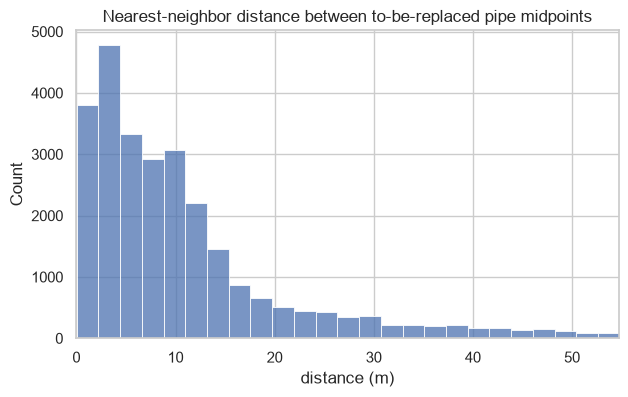

In [25]:
plt.figure(figsize=(7, 4))
sns.histplot(nn_dist, bins=60)
plt.title("Nearest-neighbor distance between to-be-replaced pipe midpoints")
plt.xlabel("distance (m)")
plt.xlim(0, np.percentile(nn_dist, 99))
plt.show()

### Map: where is the iron network, and where do leaks cluster?

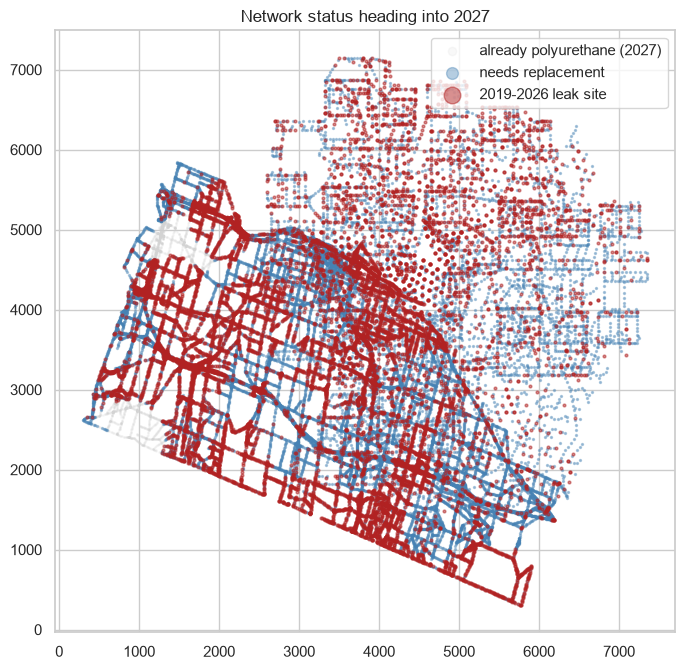

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    pipes.loc[pipes["effective_material_2027"] == "polyurethane", "GPS x1"],
    pipes.loc[pipes["effective_material_2027"] == "polyurethane", "GPS y1"],
    s=1, alpha=0.15, color="lightgray", label="already polyurethane (2027)",
)
ax.scatter(non_poly["mid_x"], non_poly["mid_y"], s=2, alpha=0.4, color="steelblue", label="needs replacement")
ax.scatter(leaks_j["GPS x1"], leaks_j["GPS y1"], s=4, alpha=0.5, color="firebrick", label="2019-2026 leak site")
ax.set_aspect("equal")
ax.legend(markerscale=6, loc="upper right")
ax.set_title("Network status heading into 2027")
plt.show()

## 5. Back-of-envelope budget check

Total available budget: $10,000,000 x 25 = $250,000,000.

The linear term alone (`$200/m` of non-poly pipe replaced) gives a hard
floor on total cost, since it doesn't depend on how circles are drawn
(every non-poly metre gets replaced exactly once, regardless of
clustering). The area^0.85 surface term is where clustering strategy can
actually save or waste money.

In [27]:
total_budget = 10_000_000 * 25
linear_cost_floor = 200 * non_poly["length_m"].sum()
groundbreaking_floor_1_per_pipe = 100 * len(non_poly)  # worst case: 1 circle per pipe

print(f"Total 25-year budget:            ${total_budget:,.0f}")
print(f"Linear-term cost floor alone:     ${linear_cost_floor:,.0f}")
print(f"Remaining for base+area terms:    ${total_budget - linear_cost_floor:,.0f}")
print(f"(worst case) $100 x one circle/pipe: ${groundbreaking_floor_1_per_pipe:,.0f}")

Total 25-year budget:            $250,000,000
Linear-term cost floor alone:     $94,355,354
Remaining for base+area terms:    $155,644,646
(worst case) $100 x one circle/pipe: $2,724,800


## Summary of findings

- **Materials**: 3 iron alloys (`wrought iron` 24,562 / `cast iron`
  10,630 / `gray iron` 3,263 -- 38,455 pipes, 89% of the network), plus
  `copper` (1,613), `brass` (1,285), and `polyurethane` (1,678, already
  compliant). "Iron" for the mandate = these 3 alloys combined; copper
  and brass are *not* mandated for replacement.
- **Already replaced before 2027**: 14,113 pipes (32.8% of the network)
  leaked in 2019-2026 and were already converted to polyurethane, even
  though `pipes.csv` still records their original material. Effective
  non-polyurethane pipes still needing a work unit in 2027: **27,248**
  (26,237 iron + 696 copper + 307 brass), totalling **471,777 m**. No
  pipe leaked more than once, and no pipe is both flagged as already-
  polyurethane in `pipes.csv` and present in `train.csv` -- the data is
  internally consistent with the "leak repairs happened pre-2027" rule.
- **Leak trend 2019-2026**: noisy but not clearly trending -- leak counts
  and total cost swing year to year (e.g. 2022 and 2026 are cost spikes)
  without a clean monotonic rise. Individual leak costs are heavily
  right-skewed (median ~$3,275, mean ~$25,012, max ~$7.26M), so a few
  extreme leaks dominate total repair cost -- avoiding tail-risk leaks
  matters more than shaving the median leak.
- **Riskiest by leaks-per-km**: `brass` is by far the riskiest material
  (68.8 leaks/km) despite not being mandated for replacement, followed by
  `wrought iron` (29.6), `copper` (14.8), `cast iron` (11.7), `gray iron`
  (8.7, least risky of the iron alloys). By surface, `farmland` (27.2) and
  `grassland` (20.8) lead; `structure` (13.5) is safest despite being the
  most expensive surface to excavate. Risk and excavation cost are
  *not* aligned, which is exactly the tension the plan needs to resolve.
- **Age**: leak rate is not monotonic in age -- pipes laid 40-60 years
  before 2019 (i.e. installed ~1959-1979) leak at 467/1000, roughly
  double the rate of both the 20-40y (212/1000) and 60-80y (210/1000)
  cohorts. This looks like an installation-era/vintage effect rather
  than simple wear-out, so risk scoring should treat lay-year cohort as
  its own signal, not just linear age. (All pipes were laid 1945-1985,
  consistent with only 3 age bins being populated.)
- **Spatial clustering**: to-be-replaced pipes are tightly packed --
  median nearest-neighbor distance 7.9 m, 75th pct 13.6 m, only a long
  thin tail out to 131 m. Small-to-moderate radius circles (tens of
  metres) can plausibly sweep up many neighboring pipes at once.
- **Budget**: $250M total. The unavoidable linear-term floor (`$200/m` x
  471,777 m of non-poly pipe, regardless of circle design) is **$94.4M**
  (~38% of budget), leaving **~$155.6M** for the base + area^0.85 terms
  combined across all work units. The $100/circle base fee is trivial
  even in the worst case of one circle per pipe (~$2.7M). This suggests
  real budget risk lives almost entirely in how large/surface-diverse the
  circles are -- not in fee counts -- and that there is meaningful slack
  for prioritizing risk reduction over pure cost minimization, provided
  circles aren't drawn carelessly large.

## Open questions for the team (see chat writeup for the full list)
1. Should we opportunistically sweep up high-risk copper/brass pipes
   into iron-targeting circles (not mandated, but brass leaks worst of
   all materials)?
2. How should the 8 unknown-`Material` water pipes be treated -- assume
   iron (safe default) or something else?
3. What risk model should drive prioritization: empirical leaks-per-km
   by (material x surface x lay-year cohort), or a fitted hazard model?
4. Any constraint on work-unit circle overlap, or a max circle count /
   radius we should assume for tractability?